# Multimodal Short-Video Recommendation System

This project aims to build a recommendation system to improve content relevance on a mobile short-video platform. The system predicts user engagement with candidate videos, measured by watch ratio, which is then used to rank candidate videos and recommend the most relevant content to users.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

In [21]:
# Load datasets
from google.colab import drive
drive.mount('/content/drive')

# Read the CSV file (update the path to match your file's directory)
behavior_df = pd.read_csv('/content/drive/MyDrive/BT4222 Data/behavior_data.csv')
user_df = pd.read_csv('/content/drive/MyDrive/BT4222 Data/user_data.csv')
video_df = pd.read_csv('/content/drive/MyDrive/BT4222 Data/video_data.csv')
categories_df = pd.read_csv('/content/drive/MyDrive/BT4222 Data/categories_cn_en.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
# Merge duration from video_df into behavior_df to compute watch_ratio
behavior_df = behavior_df.merge(video_df[['pid', 'duration']], on='pid', how='left')
behavior_df['watch_ratio'] = (behavior_df['watch_time'] / behavior_df['duration']).replace([np.inf, -np.inf], np.nan)

print(f"Behavior Data: {behavior_df.shape[0]} rows x {behavior_df.shape[1]} cols")
print(f"User Data: {user_df.shape[0]} rows x {user_df.shape[1]} cols")
print(f"Video Data: {video_df.shape[0]} rows x {video_df.shape[1]} cols")
print(f"Category Mapping: {categories_df.shape[0]} rows x {categories_df.shape[1]} cols")


Behavior Data: 1019568 rows x 15 cols
User Data: 10000 rows x 7 cols
Video Data: 153561 rows x 9 cols
Category Mapping: 826 rows x 6 cols


## Step 2: Exploratory Data Analysis (EDA)

This notebook explores the three core datasets (**user attributes**, **video attributes** and **user-video interaction records**) to understand feature distributions, engagement patterns and their relationship with the target variable, **watch ratio**.

### 2.1 Descriptive Summary

An overview of dataset dimensions and basic summary statistics.

In [23]:
# Dataset dimensions
print("=== Behavior Data ===")
print(f"Rows: {len(behavior_df):,}  |  Unique users: {behavior_df['user_id'].nunique():,}  |  Unique videos: {behavior_df['pid'].nunique():,}")
print(f"Date range: {behavior_df['p_date'].min()} → {behavior_df['p_date'].max()}")
print()

print("=== User Data ===")
print(f"Rows: {len(user_df):,}  |  Unique users: {user_df['user_id'].nunique():,}")
print()

print("=== Video Data ===")
print(f"Rows: {len(video_df):,}  |  Unique videos: {video_df['pid'].nunique():,}  |  Unique authors: {video_df['author_id'].nunique():,}")

=== Behavior Data ===
Rows: 1,019,568  |  Unique users: 10,000  |  Unique videos: 153,561
Date range: 20220916 → 20220922

=== User Data ===
Rows: 10,000  |  Unique users: 10,000

=== Video Data ===
Rows: 153,561  |  Unique videos: 153,561  |  Unique authors: 81,870


In [24]:
# Summary statistics of behavior_df
behavior_df.describe().T

,count,mean,std,min,25%,50%,75%,max
user_id,1019568.0,4.987699e+03,2883.569050,0.000000e+00,2.534000e+03,4.943000e+03,7.469000e+03,9.999000e+03
pid,1019568.0,8.448867e+04,43194.823457,0.000000e+00,4.883400e+04,9.099400e+04,1.203470e+05,1.535600e+05
exposed_time,1019568.0,1.663556e+09,156757.708383,1.663263e+09,1.663420e+09,1.663543e+09,1.663678e+09,1.663862e+09
p_date,1019568.0,2.022092e+07,1.805969,2.022092e+07,2.022092e+07,2.022092e+07,2.022092e+07,2.022092e+07
p_hour,1019568.0,1.538603e+01,5.287949,2.000000e+00,1.100000e+01,1.600000e+01,2.000000e+01,2.300000e+01
watch_time,1019568.0,3.445074e+01,56.655614,0.000000e+00,3.000000e+00,1.300000e+01,4.000000e+01,9.510000e+02
duration,1019568.0,1.010257e+02,115.409202,2.702000e+00,1.780000e+01,5.790000e+01,1.395400e+02,1.734920e+03
watch_ratio,1019568.0,6.330233e-01,0.943548,0.000000e+00,5.733094e-02,3.223844e-01,1.020942e+00,9.727517e+01


In [25]:
# Summary statistics of user_df
user_df.describe().T

,count,mean,std,min,25%,50%,75%,max
user_id,10000.0,4999.5000,2886.895680,0.0,2499.75,4999.5,7499.25,9999.0
age,10000.0,36.8345,21.616999,5.0,17.00,34.0,56.00,79.0
mod_price,10000.0,2016.9150,1474.073949,359.0,1099.00,1599.0,2399.00,17799.0


In [26]:
# Summary statistics of video_df
video_df.describe().T

,count,mean,std,min,25%,50%,75%,max
pid,153561.0,7.678000e+04,4.432939e+04,0.000,3.839000e+04,7.678000e+04,1.151700e+05,1.535600e+05
author_id,153561.0,1.696770e+09,9.432801e+08,3.000,8.440233e+08,1.830261e+09,2.588154e+09,3.022191e+09
author_fans_count,153561.0,5.420183e+05,2.357569e+06,0.000,1.589700e+04,8.373300e+04,3.808670e+05,2.164151e+08
duration,153561.0,9.372642e+01,1.105800e+02,2.702,1.638300e+01,5.210000e+01,1.285000e+02,1.734920e+03
root_id,153388.0,1.667052e+01,1.240076e+01,1.000,6.000000e+00,1.200000e+01,2.500000e+01,3.900000e+01
parent_id,101918.0,2.779644e+02,1.428687e+02,100.000,1.390000e+02,2.640000e+02,4.180000e+02,6.630000e+02
category_id,49697.0,1.494656e+03,3.627526e+02,1000.000,1.319000e+03,1.350000e+03,1.818000e+03,2.357000e+03


### 2.2 Target Variable: Watch Ratio

The target variable is **watch_ratio** = `watch_time / duration`, representing the proportion of a video watched by a user. Values > 1 indicate replays.

In [27]:
behavior_df['watch_ratio'] = (behavior_df['watch_time'] / behavior_df['duration']).replace([np.inf, -np.inf], np.nan)

wr = behavior_df['watch_ratio'].dropna()
print(f"Total interactions with valid watch_ratio: {len(wr):,}")

Total interactions with valid watch_ratio: 1,019,568


In [28]:
# Percentile distribution of watch_ratio
percentiles = [50, 75, 90, 95, 97, 99, 99.5, 99.9, 100]
print("=== Watch Ratio Percentiles ===")
for p in percentiles:
    val = np.percentile(wr, p)
    print(f"  {p:>5}th percentile:  {val:.3f}")

=== Watch Ratio Percentiles ===
     50th percentile:  0.322
     75th percentile:  1.021
     90th percentile:  1.353
     95th percentile:  2.011
     97th percentile:  2.308
     99th percentile:  3.658
   99.5th percentile:  4.886
   99.9th percentile:  9.404
    100th percentile:  97.275


In [29]:
# Coverage at various clip thresholds
thresholds = [1, 2, 3, 5, 10, 15, 20]
print("=== Data Coverage by Clip Threshold ===")
print(f"{'Threshold':>10}  {'# Included':>12}  {'% Coverage':>10}")
print("-" * 38)
for t in thresholds:
    n = (wr <= t).sum()
    pct = n / len(wr) * 100
    print(f"{t:>10}  {n:>12,}  {pct:>9.2f}%")

=== Data Coverage by Clip Threshold ===
 Threshold    # Included  % Coverage
--------------------------------------
         1       725,166      71.12%
         2       967,776      94.92%
         3     1,002,538      98.33%
         5     1,014,739      99.53%
        10     1,018,701      99.91%
        15     1,019,236      99.97%
        20     1,019,412      99.98%


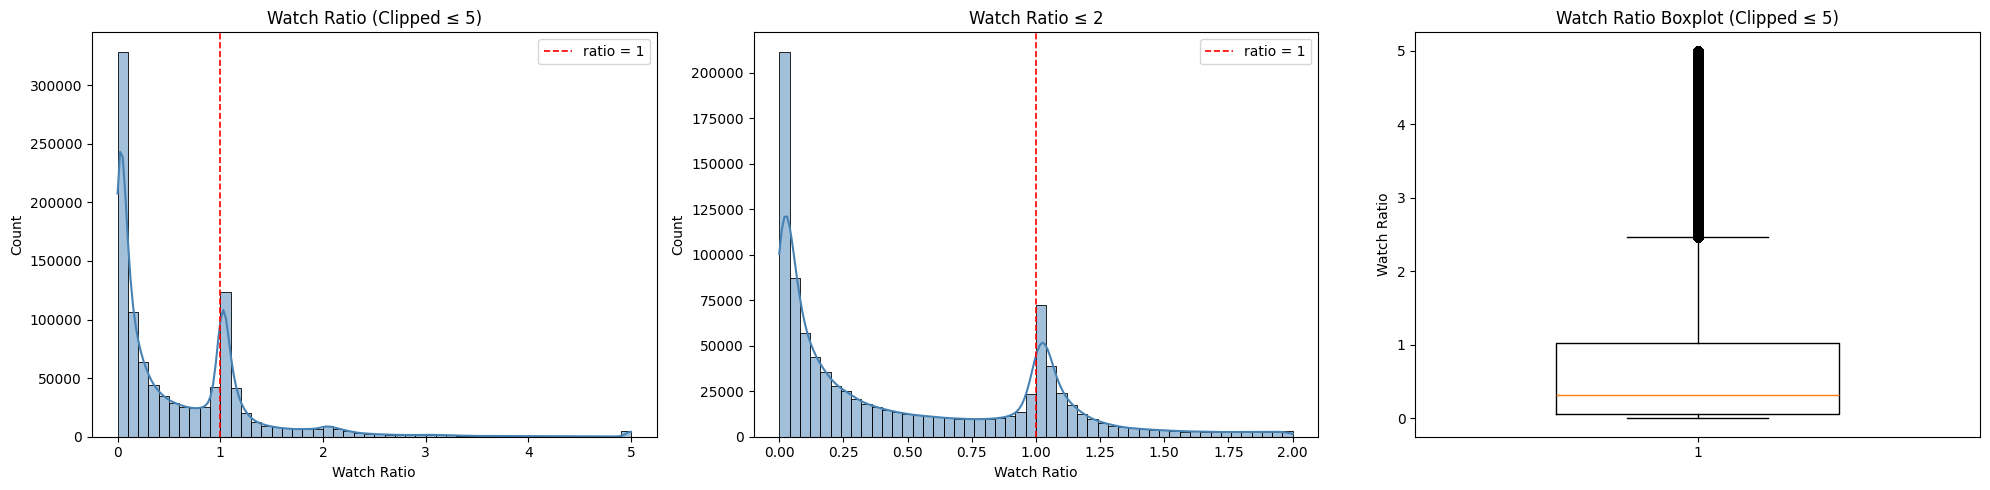

Mean watch_ratio: 0.633
Median watch_ratio: 0.322
Fraction replayed (ratio > 1): 28.88%
Fraction skipped (ratio < 0.3): 48.94%
Fraction zero (ratio == 0): 5.52%


In [30]:
# Watch_ratio distribution
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
wr_clipped = behavior_df['watch_ratio'].clip(upper=5).dropna()

for i, (data, title) in enumerate([
    (wr_clipped, 'Watch Ratio (Clipped ≤ 5)'),
    (behavior_df['watch_ratio'].dropna().loc[lambda x: x <= 2], 'Watch Ratio ≤ 2'),
    (wr_clipped, 'Watch Ratio Boxplot (Clipped ≤ 5)')
]):
    if i < 2:
        sns.histplot(data, bins=50, kde=True, ax=axes[i], color='steelblue')
        axes[i].axvline(1.0, color='red', ls='--', lw=1.2, label='ratio = 1')
        axes[i].legend()
        axes[i].set(title=title, xlabel='Watch Ratio', ylabel='Count')
    else:
        # Boxplot of watch_ratio
        axes[i].boxplot(data, vert=True, widths=0.5)
        axes[i].set(title=title, xlabel='', ylabel='Watch Ratio')

plt.tight_layout()
plt.show()

wr = behavior_df['watch_ratio'].dropna()
print(f"Mean watch_ratio: {wr.mean():.3f}")
print(f"Median watch_ratio: {wr.median():.3f}")
print(f"Fraction replayed (ratio > 1): {(wr > 1).mean():.2%}")
print(f"Fraction skipped (ratio < 0.3): {(wr < 0.3).mean():.2%}")
print(f"Fraction zero (ratio == 0): {(wr == 0).mean():.2%}")

**Analysis:**
- Watch ratio distribution is **heavily right-skewed** with a large spike near 0, indicating **many users quickly scroll past videos without meaningful engagement**. There is a notable **secondary peak around ratio = 1.0**, representing users who watch exactly one full playthrough before moving on.
- 48.94% of interactions are "skipped" (ratio < 0.3), indicating **nearly half of all exposures result in minimal engagement**. 28.88% of interactions involve replays (ratio > 1), showing a **substantial minority of users re-watch content**. 5.52% have a ratio of exactly 0 (zero watch time), suggesting the video was exposed but never played.
- The box plot confirms the IQR sits well below 1.0, with the median at ~0.32 and a long upper whisker from replay outliers.

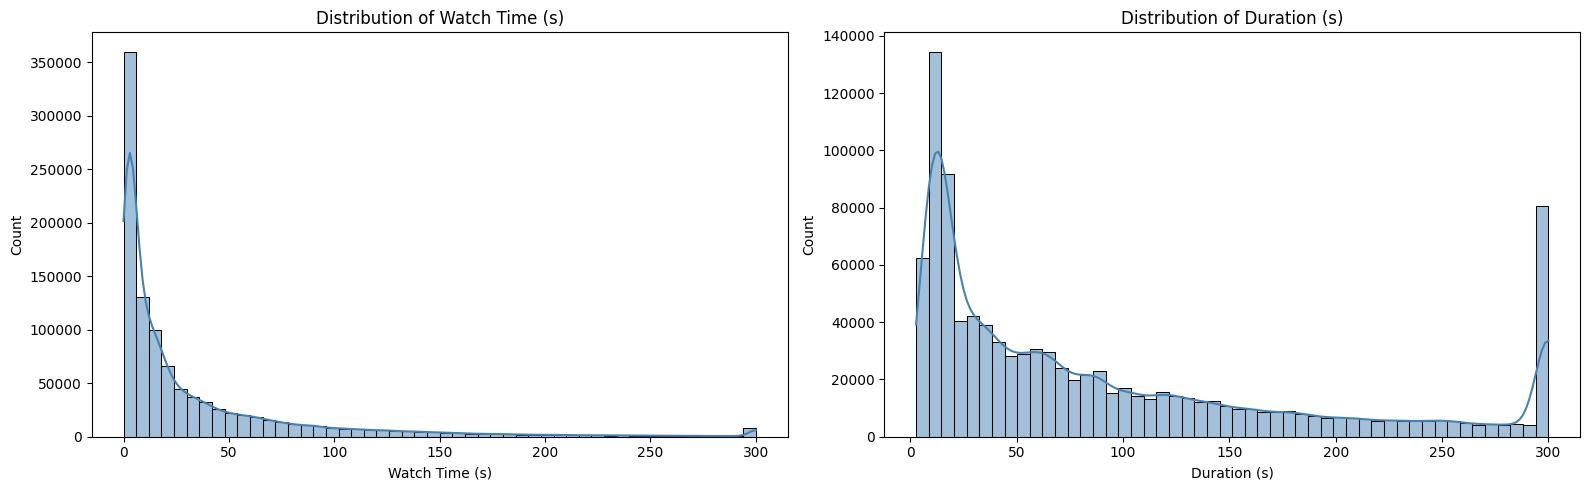

Median watch_time: 13.0s
Median duration: 57.9s


In [31]:
# Distribution of watch time and duration
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, col, label in zip(axes, ['watch_time', 'duration'], ['Watch Time (s)', 'Duration (s)']):
    sns.histplot(behavior_df[col].clip(upper=300).dropna(), bins=50, kde=True, ax=ax, color='steelblue')
    ax.set(title=f'Distribution of {label}', xlabel=label, ylabel='Count')

plt.tight_layout()
plt.show()

print(f"Median watch_time: {behavior_df['watch_time'].median():.1f}s")
print(f"Median duration: {behavior_df['duration'].median():.1f}s")

**Analysis:**
- **Watch time** is **heavily concentrated** at very short durations (median = **13.0s**), suggesting most users decide quickly whether to continue watching or scroll past. **Video duration** is **more spread out** (median = **57.9s**), with a peak in the 15–60s range, which is typical of short-video platforms, though a long tail extends to several minutes.
- The large gap between median watch time (13s) and median duration (57.9s) is consistent with the low median watch ratio of 0.322, indicating **most users leave well before the video ends**.

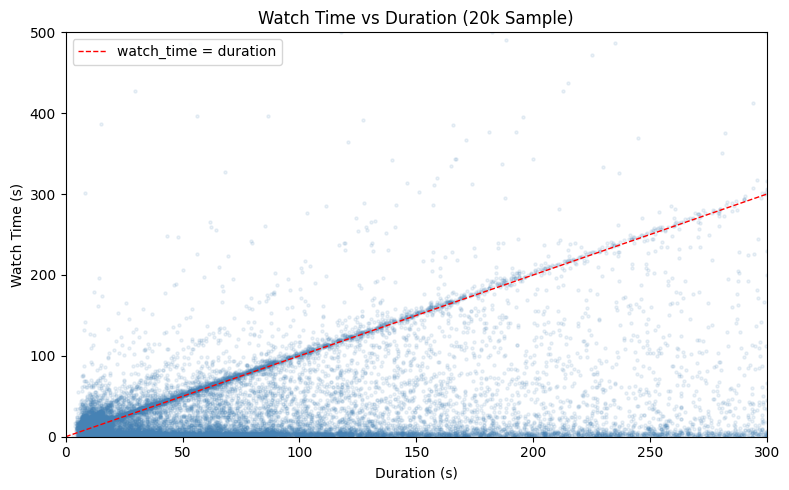

In [32]:
# Watch time vs duration
fig, ax = plt.subplots(figsize=(8, 5))
sample = behavior_df.dropna(subset=['duration']).sample(min(20000, len(behavior_df)), random_state=42)
ax.scatter(sample['duration'], sample['watch_time'].clip(upper=500),
           alpha=0.1, s=5, rasterized=True, color='steelblue')
ax.plot([0, 300], [0, 300], 'r--', lw=1, label='watch_time = duration')
ax.set(title='Watch Time vs Duration (20k Sample)', xlabel='Duration (s)', ylabel='Watch Time (s)',
       xlim=(0, 300), ylim=(0, 500))
ax.legend()
plt.tight_layout()
plt.show()

**Analysis:** In the scatter plot, majority of points cluster below the red `watch_time = duration` line, confirming that **most users do not finish watching the videos**. A dense horizontal band near low watch times (0–20s) spans all video durations, representing **quick-scroll behavior regardless of video length**. Points above the red line (replays) are more common for shorter videos, suggesting **short content is more likely to be re-watched**.

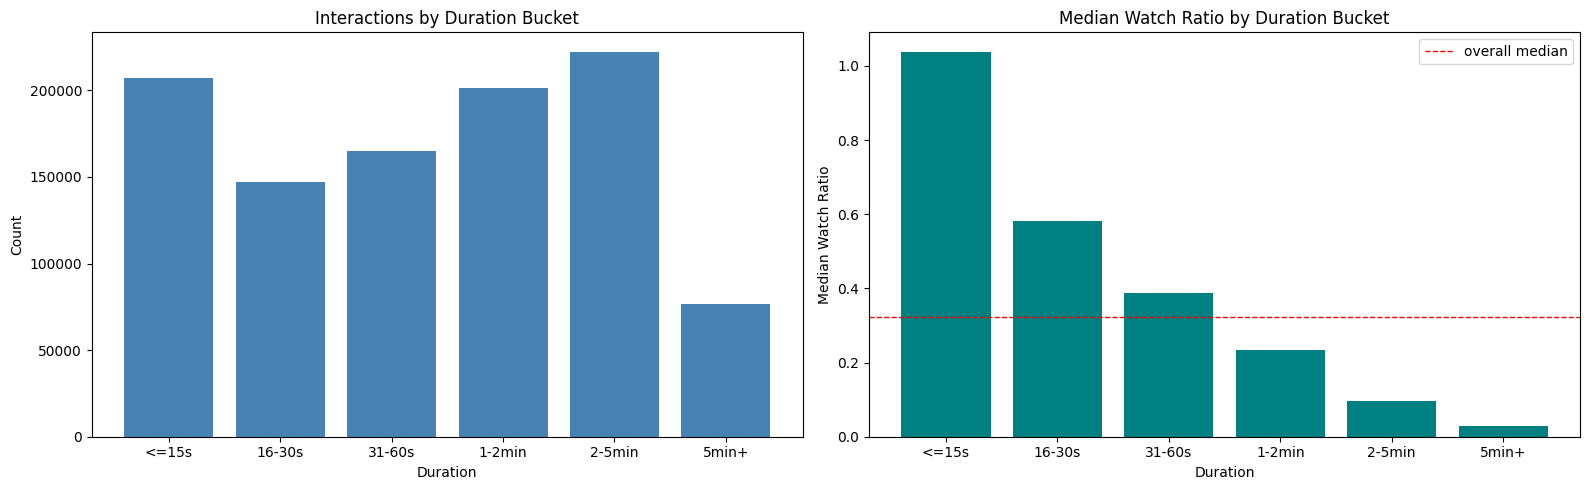

In [33]:
# Watch ratio by duration bucket
behavior_df['duration_bucket'] = pd.cut(
    behavior_df['duration'],
    bins=[0, 15, 30, 60, 120, 300, np.inf],
    labels=['<=15s', '16-30s', '31-60s', '1-2min', '2-5min', '5min+']
)

bucket_counts = behavior_df['duration_bucket'].value_counts().sort_index()
wr_bucket = behavior_df.groupby('duration_bucket', observed=True)['watch_ratio'].median()

# Interations and median watch_ratio by duration bucket
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(bucket_counts.index.astype(str), bucket_counts.values, color='steelblue')
axes[0].set(title='Interactions by Duration Bucket', xlabel='Duration', ylabel='Count')

axes[1].bar(wr_bucket.index.astype(str), wr_bucket.values, color='teal')
axes[1].axhline(behavior_df['watch_ratio'].median(), color='red', ls='--', lw=1, label='overall median')
axes[1].legend()
axes[1].set(title='Median Watch Ratio by Duration Bucket', xlabel='Duration', ylabel='Median Watch Ratio')

plt.tight_layout()
plt.show()

**Analysis:**
- The majority of interactions involve videos in the **31–60s** range, followed by **1–2 min** videos. **Very short videos (≤15s) and long videos (5min+) are less common** in the interaction pool. ### Majority -> 2-5min, <=15s? Less common -> 5min+, 16-30s
- **Shorter videos (≤15s) have a substantially higher median watch ratio**, indicating users are more likely to watch them fully or replay them. As **video duration increases, the median watch ratio** drops steadily, with 5min+ videos showing the lowest engagement. This suggests **short-form content naturally drives higher watch ratios**.

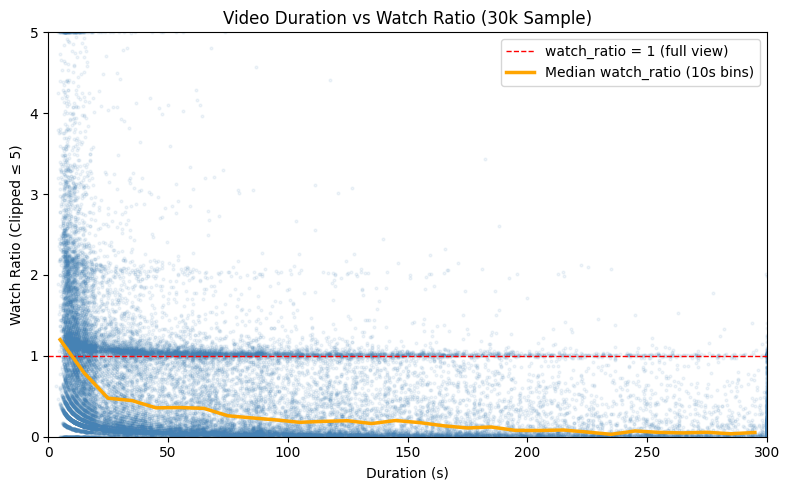

Pearson correlation (duration vs watch_ratio): -0.2709


In [34]:
# Video duration vs watch_ratio
fig, ax = plt.subplots(figsize=(8, 5))
sample = behavior_df.dropna(subset=['watch_ratio']).sample(min(30000, len(behavior_df)), random_state=42)
ax.scatter(sample['duration'].clip(upper=300), sample['watch_ratio'].clip(upper=5),
           alpha=0.08, s=4, rasterized=True, color='steelblue')
ax.axhline(1.0, color='red', ls='--', lw=1, label='watch_ratio = 1 (full view)')

dur_bins = pd.cut(sample['duration'], bins=np.arange(0, 310, 10))
median_line = sample.groupby(dur_bins, observed=True)['watch_ratio'].median()
bin_centers = [interval.mid for interval in median_line.index]
ax.plot(bin_centers, median_line.values, color='orange', lw=2.5, label='Median watch_ratio (10s bins)')
ax.set(title='Video Duration vs Watch Ratio (30k Sample)', xlabel='Duration (s)',
       ylabel='Watch Ratio (Clipped ≤ 5)', xlim=(0, 300), ylim=(0, 5))
ax.legend()
plt.tight_layout()
plt.show()

corr_val = behavior_df[['duration', 'watch_ratio']].dropna().corr().iloc[0, 1]
print(f"Pearson correlation (duration vs watch_ratio): {corr_val:.4f}")

**Analysis**

- There is a **negative correlation** between video duration and watch ratio. The orange median line drops steeply for the first ~60 seconds, then gradually levels off.
- **Very short videos (≤15s)** have median watch ratios well above 1.0, indicating users frequently replay them. For **videos longer than ~60s**, the median watch ratio stabilises below 0.5, suggesting most users watch less than half before scrolling away.
- The scatter plot shows a dense cluster of low watch ratios across all durations, confirming that **quick-scroll behavior is duration-agnostic** - many users decide within seconds whether to engage regardless of video length.

### 2.3 User Attributes

User-level features include `gender`, `age`, `mod_price` (phone price), `fre_city`, `fre_community_type`, `fre_city_level`.

In [35]:
# Merge user attributes into behavior data for cross-analysis
user_behavior = behavior_df.merge(user_df, on='user_id', how='left')

#### 2.3.1 Gender

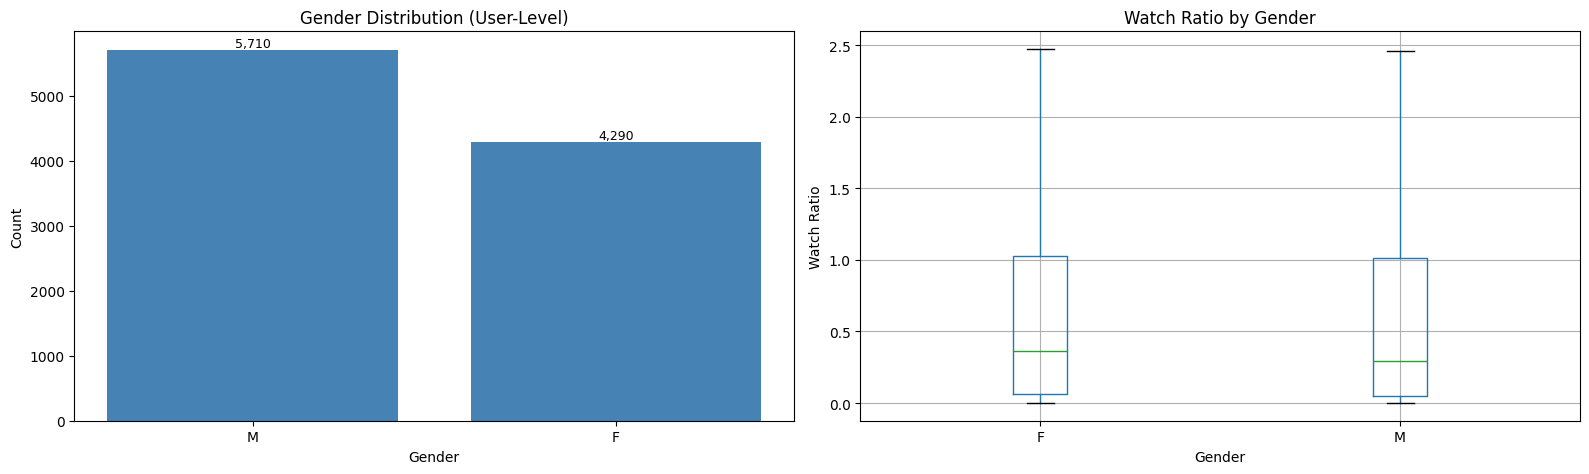

Median watch_ratio: 0.3224
gender
F    0.363636
M    0.293731
Name: watch_ratio, dtype: float64


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
gender_counts = user_df['gender'].value_counts()

# Gender distribution
axes[0].bar(gender_counts.index.astype(str), gender_counts.values, color='steelblue')
for j, val in enumerate(gender_counts.values):
    axes[0].text(j, val + 50, f'{val:,}', ha='center', fontsize=9)
axes[0].set(title='Gender Distribution (User-Level)', xlabel='Gender', ylabel='Count')

# Watch_ratio by gender
user_behavior.boxplot(column='watch_ratio', by='gender', ax=axes[1], showfliers=False)
axes[1].get_figure().suptitle('')
axes[1].set(title='Watch Ratio by Gender', xlabel='Gender', ylabel='Watch Ratio')

plt.tight_layout()
plt.show()

print(f"Median watch_ratio: {user_behavior['watch_ratio'].median():.4f}")
print(user_behavior.groupby('gender')['watch_ratio'].median())

**Analysis:**
- User dataset containes more males than females.
- The box plots show similar watch ratio distributions across genders. The median, IQR and whisker ranges are nearly identical, suggesting **gender has minimal influence** on how much of a video a user watches. Gender alone is unlikely to be a strong predictor of watch ratio.


#### 2.3.2 Age

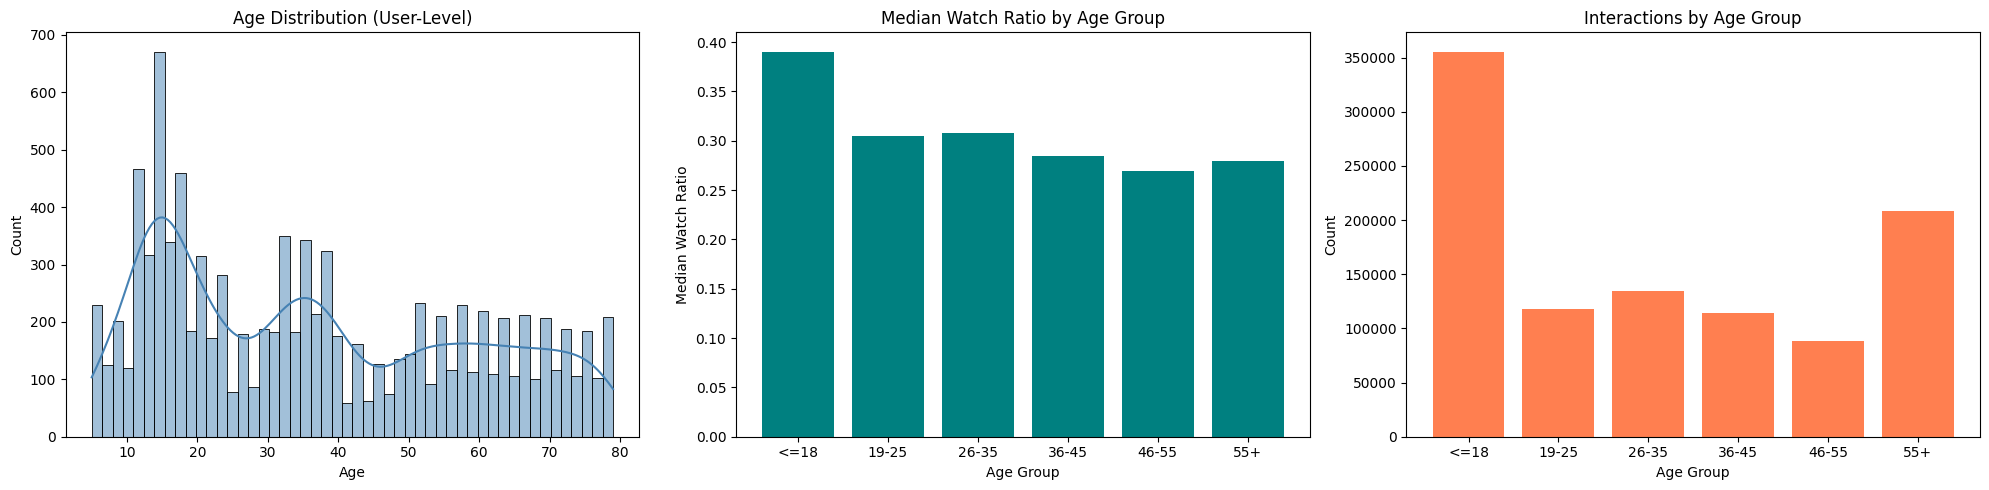

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Age distribution
sns.histplot(user_df['age'].dropna(), bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set(title='Age Distribution (User-Level)', xlabel='Age', ylabel='Count')

# Bucket age into bins
user_behavior['age_bin'] = pd.cut(
    user_behavior['age'], bins=[0, 18, 25, 35, 45, 55, 100],
    labels=['<=18', '19-25', '26-35', '36-45', '46-55', '55+']
)

wr_age = user_behavior.groupby('age_bin', observed=True)['watch_ratio'].median()
vol_age = user_behavior.groupby('age_bin', observed=True).size()

# Median watch_ratio by age group
axes[1].bar(wr_age.index.astype(str), wr_age.values, color='teal')
axes[1].set(title='Median Watch Ratio by Age Group', xlabel='Age Group', ylabel='Median Watch Ratio')

# Interactions by age group
axes[2].bar(vol_age.index.astype(str), vol_age.values, color='coral')
axes[2].set(title='Interactions by Age Group', xlabel='Age Group', ylabel='Count')

plt.tight_layout()
plt.show()

**Analysis:**
- The age distribution is **multimodal**, with notable peaks around ages 11–15 (minors), 33–37 and a long tail toward older users.
- **Younger users (35 and below) show a slightly higher median** than older users (above 35), with users ≤18 having the highest median watch ratio.
- The **≤18 age group dominates** interaction volume, followed by 55+ and 26–35, together accounting for the majority of the data. Middle-aged users (36–45, 46–55) contribute fewer interactions.


#### 2.3.3 City Level & Community Type

In [38]:
# Translate city level and community type from Chinese to English
city_level_map = {
    '一线城市': 'Tier 1 City', '新一线城市': 'New Tier 1 City',
    '二线城市': 'Tier 2 City', '三线城市': 'Tier 3 City',
    '四线城市': 'Tier 4 City', '五线城市': 'Tier 5 City',
    'unknown': 'Unknown'
}
community_map = {
    '城区': 'Urban Area', '镇区': 'Town', '乡村': 'County', 'unknown': 'Unknown'
}

user_df['city_level_en'] = user_df['fre_city_level'].map(city_level_map).fillna(user_df['fre_city_level'])
user_behavior['city_level_en'] = user_behavior['fre_city_level'].map(city_level_map).fillna(user_behavior['fre_city_level'])
user_df['community_en'] = user_df['fre_community_type'].map(community_map).fillna(user_df['fre_community_type'])
user_behavior['community_en'] = user_behavior['fre_community_type'].map(community_map).fillna(user_behavior['fre_community_type'])

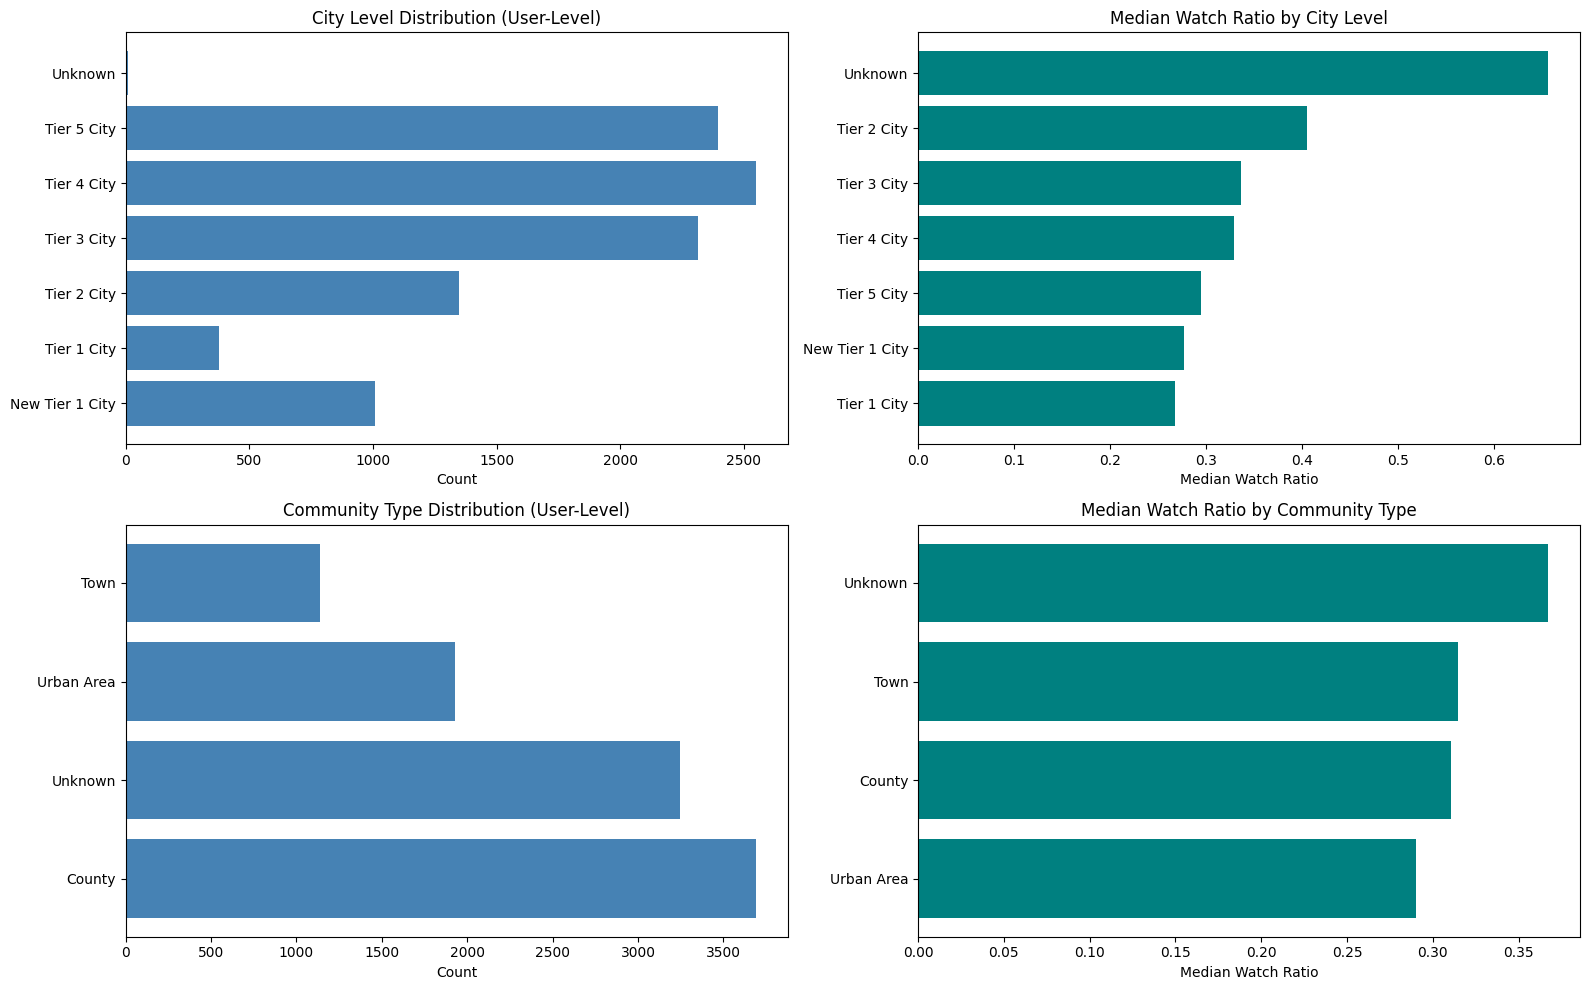

In [39]:
# City and community type distribution, and median_watch ratio by city and community type level
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
city_counts = user_df['city_level_en'].value_counts().sort_index()
wr_city = user_behavior.groupby('city_level_en')['watch_ratio'].median().sort_values()
comm_counts = user_df['community_en'].value_counts()
wr_comm = user_behavior.groupby('community_en')['watch_ratio'].median().sort_values()

for ax, (labels, vals, title, xlabel, color) in zip(axes.flatten(), [
    (city_counts.index, city_counts.values, 'City Level Distribution (User-Level)', 'Count', 'steelblue'),
    (wr_city.index, wr_city.values, 'Median Watch Ratio by City Level', 'Median Watch Ratio', 'teal'),
    (comm_counts.index, comm_counts.values, 'Community Type Distribution (User-Level)', 'Count', 'steelblue'),
    (wr_comm.index, wr_comm.values, 'Median Watch Ratio by Community Type', 'Median Watch Ratio', 'teal'),
]):
    ax.barh(labels.astype(str), vals, color=color)
    ax.set(title=title, xlabel=xlabel, ylabel='')

plt.tight_layout()
plt.show()

**Analysis:**
- Lower-tier (3-5) cities tend to have **slightly higher watch ratios**, which aligns with the typical user base of short-video platforms in China, where **penetration is strongest outside tier-1 cities**. This could be possibly due to different content consumption habits (eg. more leisure time, different content preferences).
- **Tier 2 city users have the highest median watch ratios** (~0.40), meaning they watch a larger proportion of each video
- **"Country" dominates** the user base, with a large number of users falling under "unknown" category. This aligns with the city-level data, where country users vastly outnumber urban ones.
- The median watch ratio is **rather similar across community types** (0.29-0.31).


#### 2.3.4 Phone Price (mod_price)

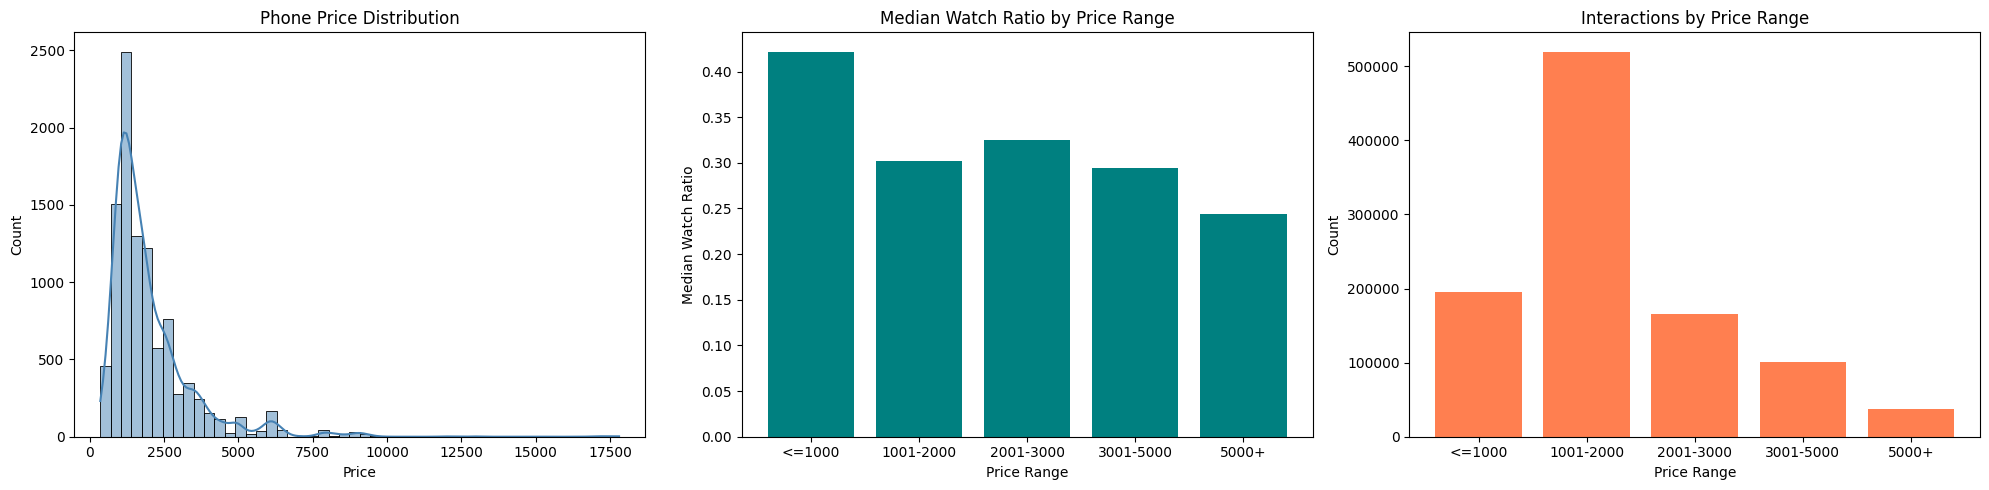

In [40]:
# Bucket mod_price into bins
user_behavior['price_bin'] = pd.cut(
    user_behavior['mod_price'],
    bins=[0, 1000, 2000, 3000, 5000, np.inf],
    labels=['<=1000', '1001-2000', '2001-3000', '3001-5000', '5000+']
)

wr_price = user_behavior.groupby('price_bin', observed=True)['watch_ratio'].median()
vol_price = user_behavior.groupby('price_bin', observed=True).size()

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Phone price distribution
sns.histplot(user_df['mod_price'].dropna(), bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set(title='Phone Price Distribution', xlabel='Price', ylabel='Count')

# Median watch_ratio by price range
axes[1].bar(wr_price.index.astype(str), wr_price.values, color='teal')
axes[1].set(title='Median Watch Ratio by Price Range', xlabel='Price Range', ylabel='Median Watch Ratio')

# Interactions by price range
axes[2].bar(vol_price.index.astype(str), vol_price.values, color='coral')
axes[2].set(title='Interactions by Price Range', xlabel='Price Range', ylabel='Count')

plt.tight_layout()
plt.show()

**Analysis:**
- Phone price may serve as a **proxy for socioeconomic status**. The distribution has a **sharp peak around 1000–1500**.
- Users with the **lowest-priced devices (≤1000) have the highest median watch ratio** (\~0.42), noticeably above all other groups, while the most expensive devices (5000+) show the lowest engagement (\~0.25). There's a slight bump at the 2001–3000 range (\~0.33), but the **overall trend is downward**.
- The **1001–2000 price range** has the highest interaction volume, representing the largest user segment. The premium ends have fewer users.


### 2.4 Video Attributes

Video-level features include `duration`, `author_id`, `author_fans_count`, `tags`, and category hierarchy (`root_id`, `parent_id`, `category_id`).

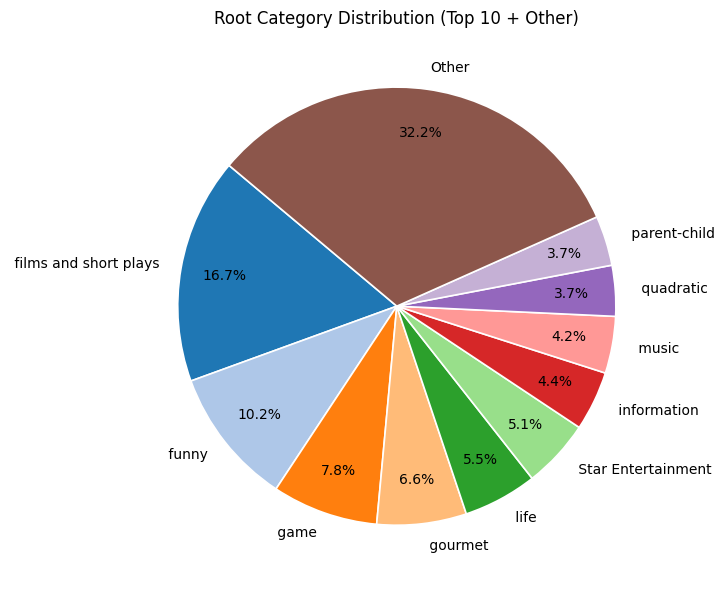

Total root categories: 36
Top 10 categories cover 67.8% of all interactions


In [41]:
# Root category distribution
cat_name_map = dict(zip(categories_df['category_id'], categories_df['category_name_en']))
video_with_cat = video_df.copy()
video_with_cat['root_category'] = video_with_cat['root_id'].map(cat_name_map)
vid_behavior = behavior_df.merge(video_with_cat[['pid', 'root_category']], on='pid', how='left')

cat_counts = vid_behavior['root_category'].value_counts()
top_slice = cat_counts.head(10)
pie_data = pd.concat([top_slice, pd.Series({'Other': cat_counts.iloc[10:].sum()})])

fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(pie_data.values, labels=pie_data.index, autopct='%1.1f%%',
       startangle=140, pctdistance=0.8, colors=plt.cm.tab20.colors[:len(pie_data)],
       wedgeprops=dict(edgecolor='white', linewidth=1.2))
ax.set(title='Root Category Distribution (Top 10 + Other)')
plt.tight_layout()
plt.show()

print(f"Total root categories: {cat_counts.nunique()}")
print(f"Top 10 categories cover {top_slice.sum() / cat_counts.sum():.1%} of all interactions")

**Analysis:**

- The pie chart reveals a **highly concentrated content mix**, where the top 10 root categories account for the majority of all interactions, while the remaining categories collectively form a small "Other" slice.
- A **few dominant categories command a disproportionate share of user attention**, which is typical of content platforms where a **small number of popular genres drive most traffic**.
- The long tail of niche categories, while individually small, may still be **important for personalisation** as users with niche interests may have higher engagement when served their preferred content, even if those categories are globally unpopular.

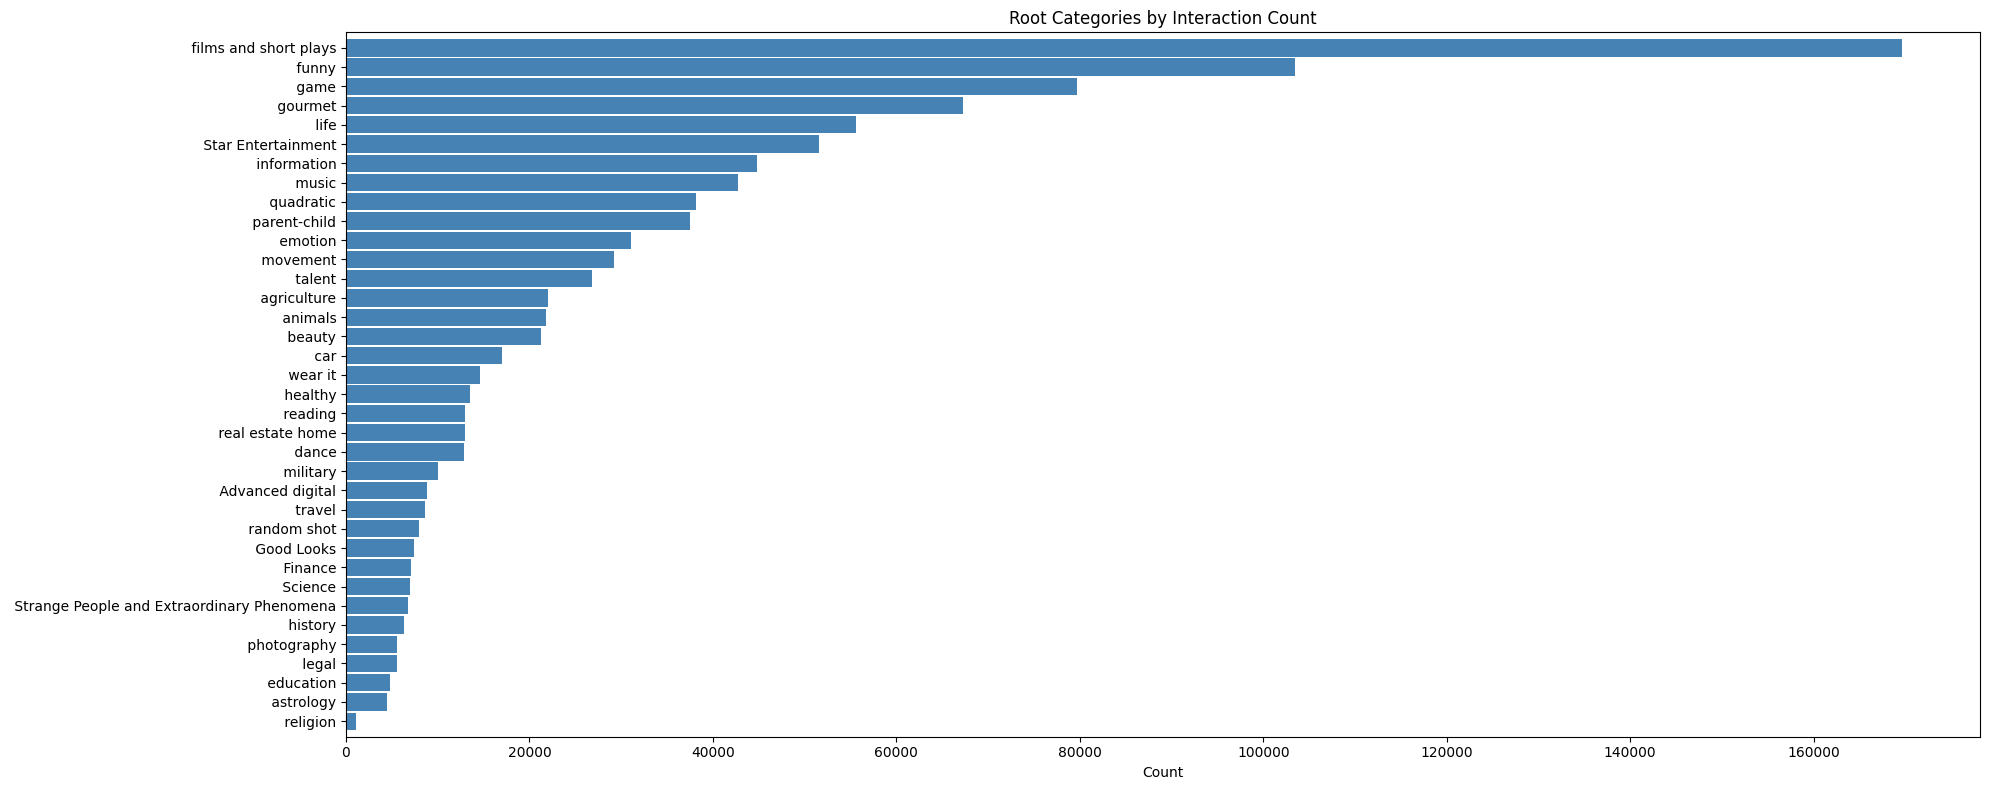

In [42]:
# Root categories by interaction count
top_cats = vid_behavior['root_category'].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(20, 8))
ax.barh(top_cats.index.astype(str), top_cats.values, color='steelblue', height=0.9)
ax.set(title='Root Categories by Interaction Count', xlabel='Count', ylabel='')
ax.margins(y=0.01)
plt.tight_layout()
plt.show()

**Analysis:** User interactions are **heavily concentrated in entertainment-related content**, especially films and humour. The **long tail of niche categories** has far fewer interactions. For example, educational and specialised content (eg. science, history, education) have much lower counts.

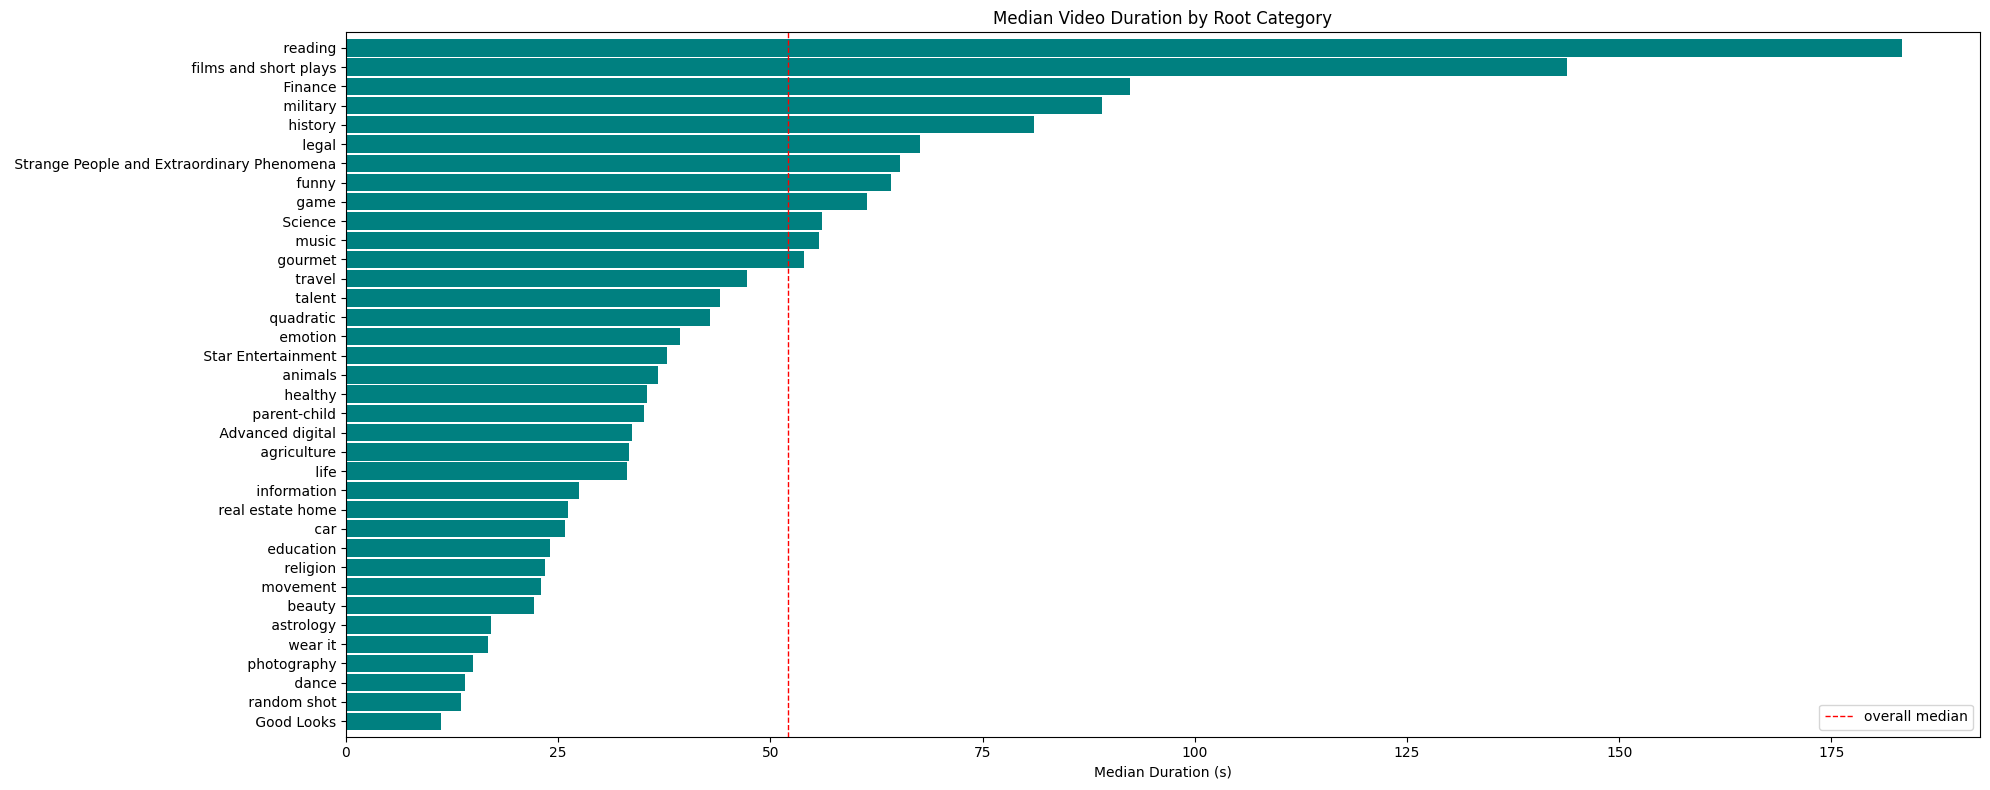

Overall median duration: 52.1s
Category with longest median duration:  reading (183.3s)
Category with shortest median duration:  Good Looks (11.2s)


In [43]:
# Median video duration by root category
vid_with_cat = video_df.merge(
    pd.DataFrame({'root_id': categories_df['category_id'], 'root_category': categories_df['category_name_en']}),
    on='root_id', how='left'
)
avg_dur_cat = (
    vid_with_cat[vid_with_cat['root_category'].isin(vid_behavior['root_category'].value_counts().index)]
    .groupby('root_category')['duration'].median().sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(20, 8))
ax.barh(avg_dur_cat.index.astype(str), avg_dur_cat.values, color='teal', height=0.9)
ax.axvline(video_df['duration'].median(), color='red', ls='--', lw=1, label='overall median')
ax.legend()
ax.set(title='Median Video Duration by Root Category', xlabel='Median Duration (s)', ylabel='')
ax.margins(y=0.01)
plt.tight_layout()
plt.show()

print(f"Overall median duration: {video_df['duration'].median():.1f}s")
print(f"Category with longest median duration: {avg_dur_cat.idxmax()} ({avg_dur_cat.max():.1f}s)")
print(f"Category with shortest median duration: {avg_dur_cat.idxmin()} ({avg_dur_cat.min():.1f}s)")

**Analysis:** There is **substantial variation** in median video duration across root categories. Some categories naturally have shorter content (eg. dance, looks) while others tend toward longer formats (eg. education, entertainment).

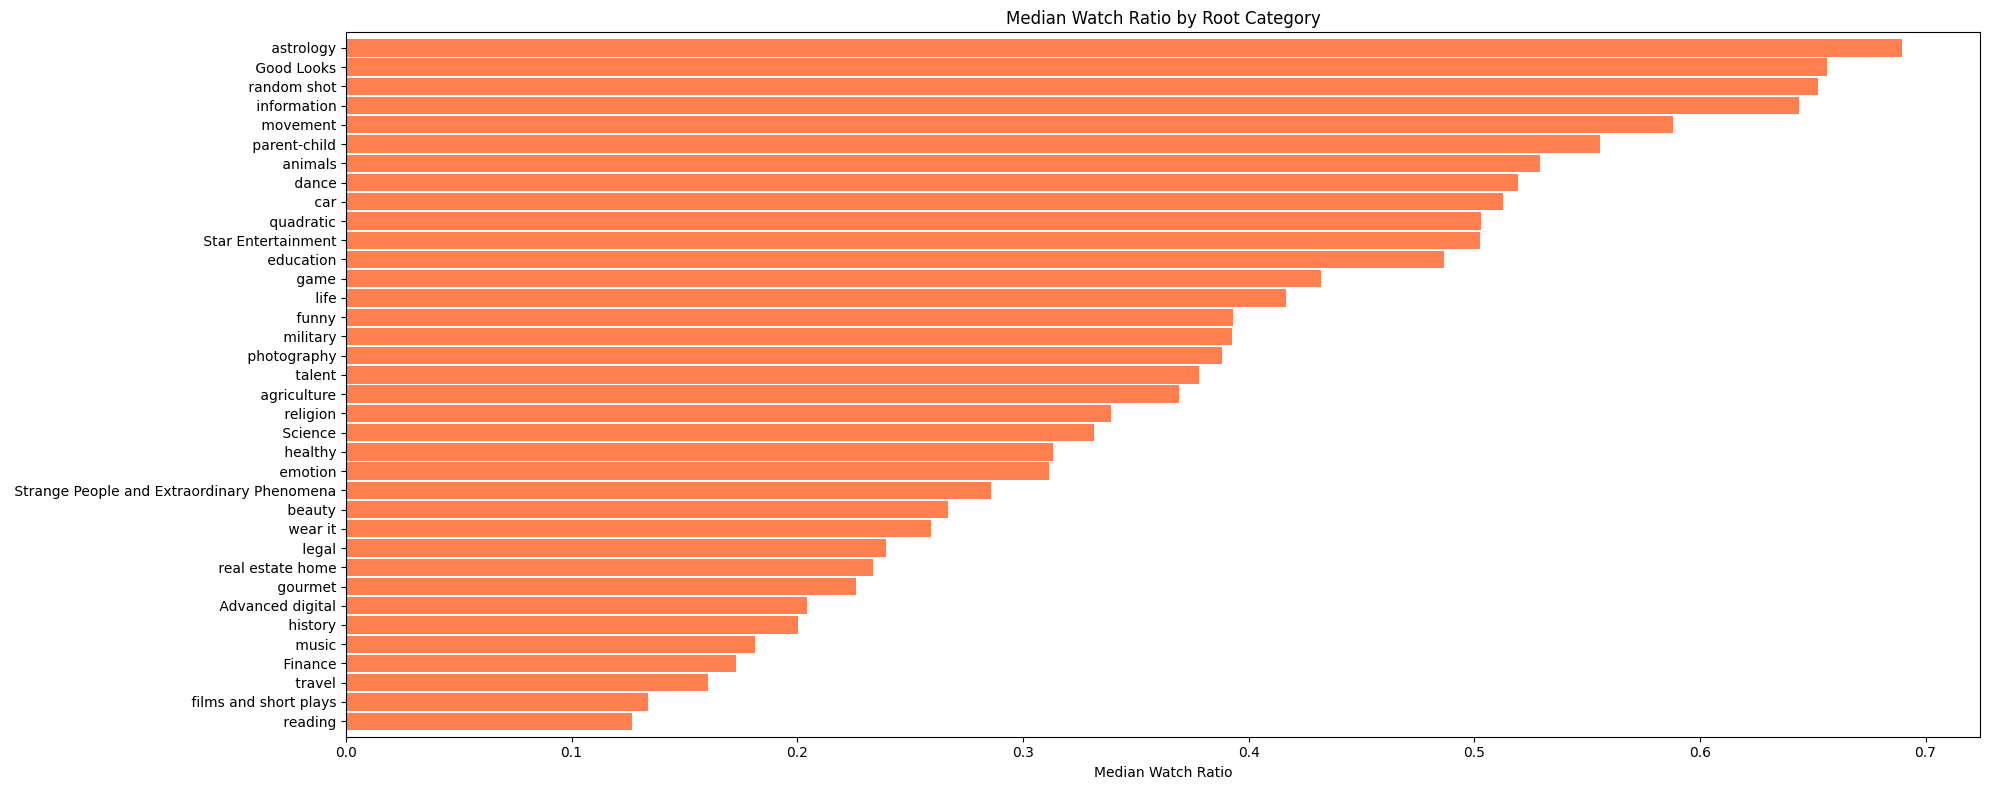

In [44]:
# Median watch_ratio by root category
wr_cat = (
    vid_behavior[vid_behavior['root_category'].isin(top_cats.index)]
    .groupby('root_category')['watch_ratio'].median().sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(20, 8))
ax.barh(wr_cat.index.astype(str), wr_cat.values, color='coral', height=0.9)
ax.set(title='Median Watch Ratio by Root Category', xlabel='Median Watch Ratio', ylabel='')
ax.margins(y=0.01)
plt.tight_layout()
plt.show()

**Analysis:** Attention (watch_ratio) is **highest for curiosity-driven, visually appealing or personally relevant content**, while traditional entertainment and professional topics lag behind. However, none of the categories have a watch_ratio > 1.0, indicating that viewers **generally do not watch content in full**.

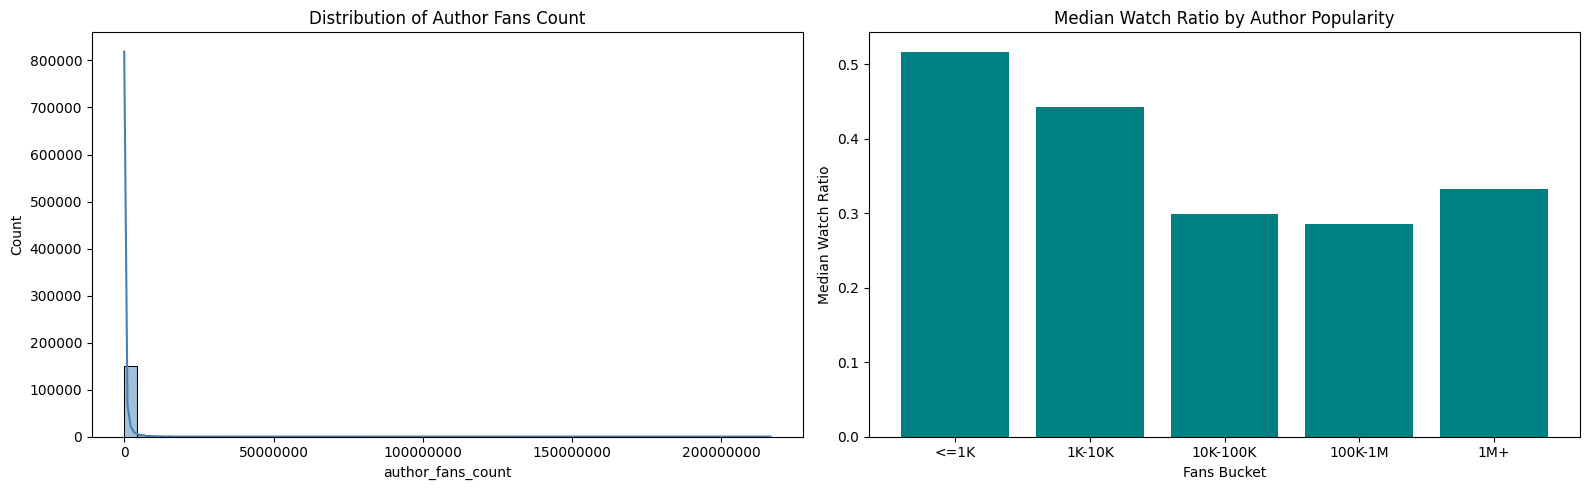

author_fans_count -- median: 83,733, mean: 542,018, max: 216,415,051
Unique authors: 81,870
Videos per author -- median: 1, mean: 1.9, max: 102


In [45]:
vid_behavior2 = behavior_df.merge(video_df[['pid', 'author_fans_count']], on='pid', how='left')
vid_behavior2['fans_bucket'] = pd.cut(
    vid_behavior2['author_fans_count'],
    bins=[0, 1000, 10000, 100000, 1000000, np.inf],
    labels=['<=1K', '1K-10K', '10K-100K', '100K-1M', '1M+']
)
wr_fans = vid_behavior2.groupby('fans_bucket', observed=True)['watch_ratio'].median()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution of author fans count
sns.histplot(video_df['author_fans_count'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set(title='Distribution of Author Fans Count', xlabel='author_fans_count', ylabel='Count')
axes[0].ticklabel_format(style='plain', axis='x')

# Median watch ratio by author popularity
axes[1].bar(wr_fans.index.astype(str), wr_fans.values, color='teal')
axes[1].set(title='Median Watch Ratio by Author Popularity', xlabel='Fans Bucket', ylabel='Median Watch Ratio')

plt.tight_layout()
plt.show()

fans = video_df['author_fans_count']
print(f"author_fans_count -- median: {fans.median():,.0f}, mean: {fans.mean():,.0f}, max: {fans.max():,.0f}")
print(f"Unique authors: {video_df['author_id'].nunique():,}")
vids_per_author = video_df.groupby('author_id').size()
print(f"Videos per author -- median: {vids_per_author.median():.0f}, mean: {vids_per_author.mean():.1f}, max: {vids_per_author.max()}")

**Analysis:**

- `author_fans_count` follows a **highly skewed, heavy-tailed distribution** where the majority of authors have few fames, while a small number of extreme outliers (millions) dominate the scale. For modelling, `author_fans_count` should be **log-transformed** given its power-law distribution.
- There is **no linear relationship** between author popularity and `watch_ratio`. Authors with **very small followings (<=1K fans) have the highest median watch ratios**, suggesting that niche or new creators can drive strong engagement. Larger creators (1M+ fans) show lower median engagement, possibly due to more passive or casual viewership.
- The median author publishes only 1 video in the dataset (mean 1.9), indicating that most authors are **infrequent creators**.

### 2.5 User-Video Interaction Attributes

Interaction-level features include engagement signals (`click`, `cvm_like`, `comment`, `follow`, `collect`, `forward`, `hate`) and temporal context (`p_hour`, `p_date`).

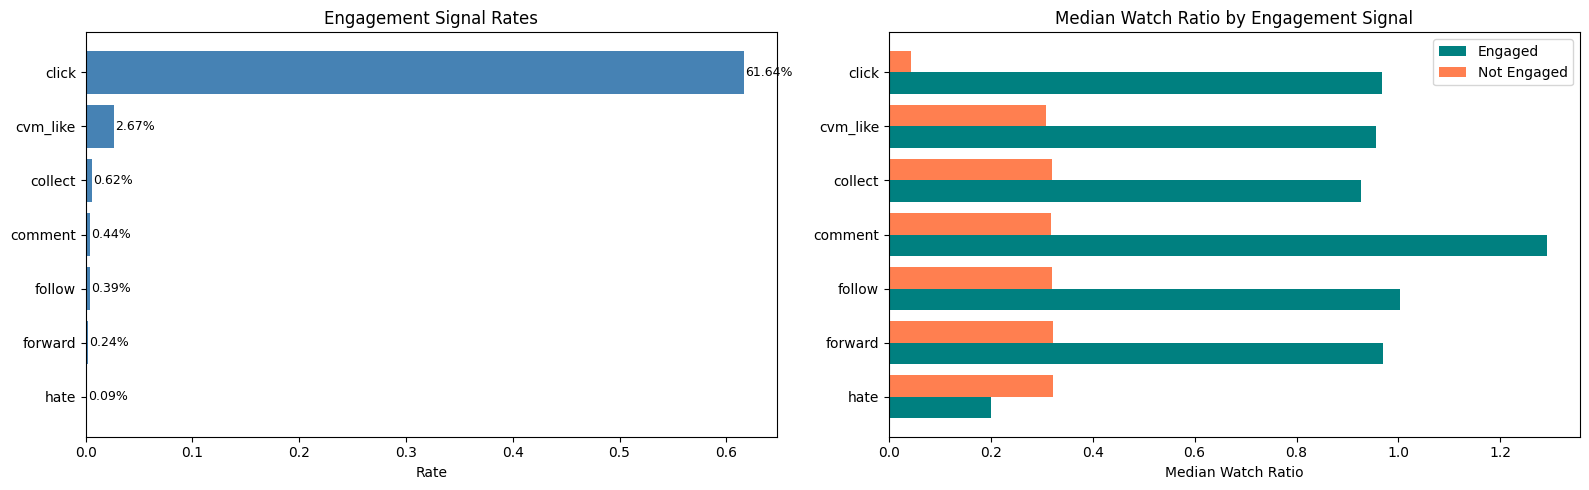

In [46]:
engagement_cols = ['click', 'cvm_like', 'comment', 'follow', 'collect', 'forward', 'hate']
eng_rates = behavior_df[engagement_cols].mean().sort_values(ascending=True)

wr_by_eng = {}
for col in engagement_cols:
    wr_by_eng[col] = {
        'engaged': behavior_df.loc[behavior_df[col] == True, 'watch_ratio'].median(),
        'not_engaged': behavior_df.loc[behavior_df[col] == False, 'watch_ratio'].median(),
    }
wr_eng_df = pd.DataFrame(wr_by_eng).T.loc[eng_rates.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Engagement signal rates
axes[0].barh(eng_rates.index.astype(str), eng_rates.values, color='steelblue')
for j, v in enumerate(eng_rates.values):
    axes[0].text(v + 0.001, j, f'{v:.2%}', va='center', fontsize=9)
axes[0].set(title='Engagement Signal Rates', xlabel='Rate', ylabel='')

# Median watch_ratio by engagement signal
y = np.arange(len(wr_eng_df))
axes[1].barh(y - 0.2, wr_eng_df['engaged'], height=0.4, label='Engaged', color='teal')
axes[1].barh(y + 0.2, wr_eng_df['not_engaged'], height=0.4, label='Not Engaged', color='coral')
axes[1].set_yticks(y)
axes[1].set_yticklabels(wr_eng_df.index.astype(str))
axes[1].legend()
axes[1].set(title='Median Watch Ratio by Engagement Signal', xlabel='Median Watch Ratio', ylabel='')

plt.tight_layout()
plt.show()

**Analysis:**
- Engagement signal rates are **very low** overall, which is typical for implicit-feedback platforms. `click` is the most common action, while `comment`, `follow`, `collect`, and `forward` are rare (each below ~5%). The `hate` signal has the lowest rate, indicating that **explicitly negative feedback is uncommon**.
- **Users who engage (like, comment, collect, follow, forward) have higher median watch ratios** than non-engaged users, sugegsting a strong positive association between engagement signals and viewing depth.
- However, engagement signals are available **only after the fact**, whereby they capture user intent that co-occurs with or follows viewing. Using them as features for predicting watch ratio would cause **data leakage** unless the model uses only historical engagement signals from prior interactions.

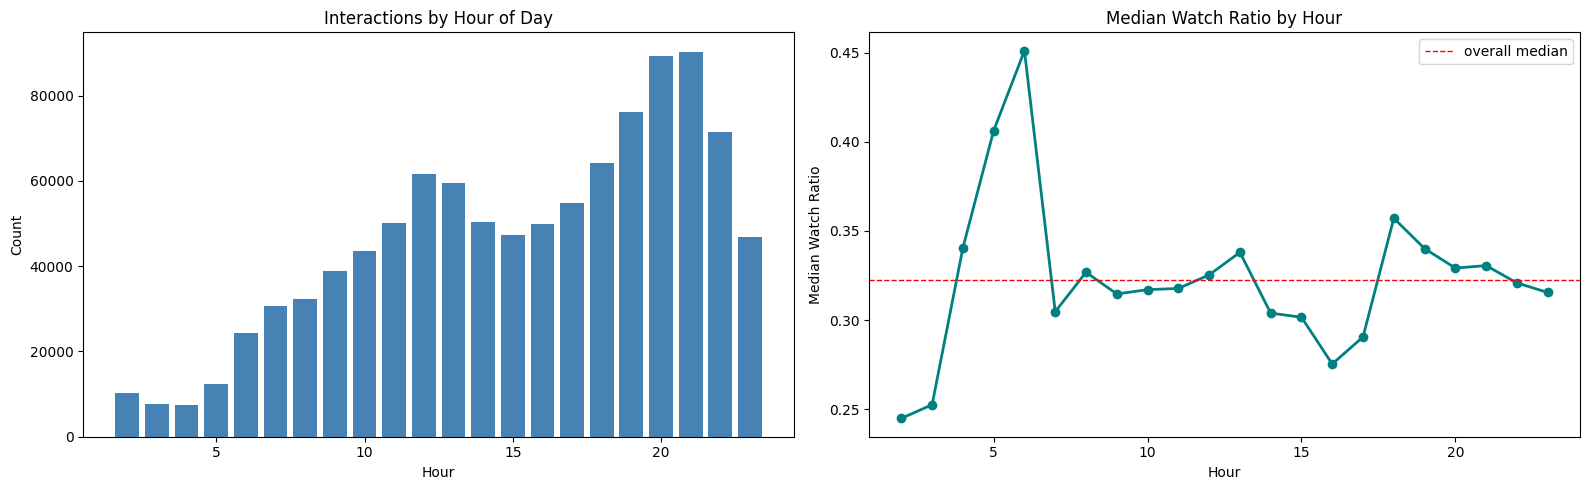

In [47]:
hour_counts = behavior_df['p_hour'].value_counts().sort_index()
wr_hour = behavior_df.groupby('p_hour')['watch_ratio'].median().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Interactions (video views) by hour of day
axes[0].bar(hour_counts.index, hour_counts.values, color='steelblue')
axes[0].set(title='Interactions by Hour of Day', xlabel='Hour', ylabel='Count')

# Median watch_ratio by hour
axes[1].plot(wr_hour.index, wr_hour.values, marker='o', color='teal', lw=2)
axes[1].axhline(behavior_df['watch_ratio'].median(), color='red', ls='--', lw=1, label='overall median')
axes[1].legend()
axes[1].set(title='Median Watch Ratio by Hour', xlabel='Hour', ylabel='Median Watch Ratio')

plt.tight_layout()
plt.show()

**Analysis:**

- Interaction volume peaks during **evening hours (18:00–22:00)** which is consistent with typical short-video platform usage after work/school, with maximum views around 90,000. There is a **secondary smaller peak around lunch (12:00–13:00)** and a **trough in the early morning hours (02:00–06:00)** with < 20,000 views.
- There is a spike during early morning (6:00) and another smaller spike immediately after work hours (18:00), reflecting more intentional.

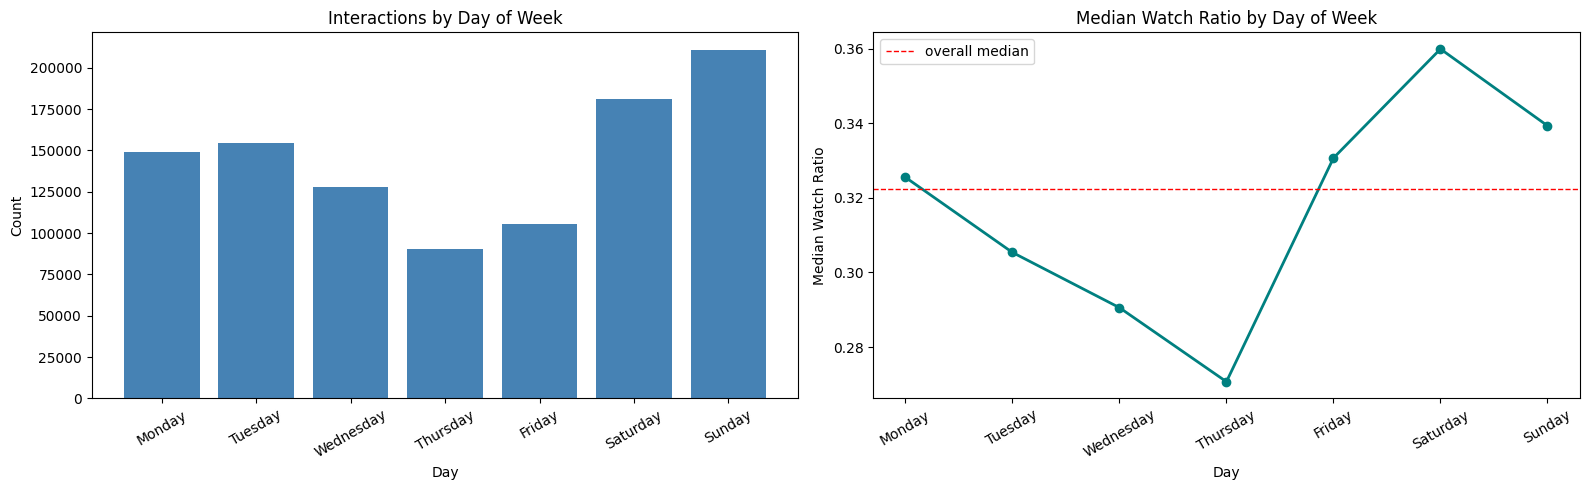

In [48]:
behavior_df['p_date_dt'] = pd.to_datetime(behavior_df['p_date'].astype(str), format='%Y%m%d')
behavior_df['day_of_week'] = behavior_df['p_date_dt'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_counts = behavior_df['day_of_week'].value_counts().reindex(day_order)
wr_dow = behavior_df.groupby('day_of_week')['watch_ratio'].median().reindex(day_order)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Interactions (video views) by day of week
axes[0].bar(dow_counts.index, dow_counts.values, color='steelblue')
axes[0].set(title='Interactions by Day of Week', xlabel='Day', ylabel='Count')

# Median watch_ratio by day of week
axes[1].plot(wr_dow.index, wr_dow.values, marker='o', color='teal', lw=2)
axes[1].axhline(behavior_df['watch_ratio'].median(), color='red', ls='--', lw=1, label='overall median')
axes[1].legend()
axes[1].set(title='Median Watch Ratio by Day of Week', xlabel='Day', ylabel='Median Watch Ratio')

for ax in axes:
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**Analysis:**

- Sunday shows the highest number of video views around 212,500 views, while Thursday shows the lowest number of video views around 87,500 views. **Weekends have higher viewership than weekdays**, reflecting behavioral patterns (eg. more leisure browsing on weekends).
- Median watch_ratio **dips steadily through the weekdays**, bottoms out on Thursday (0.275) and **rebounds strongly on weekends**, with Saturday (0.36) showing the highest engagement.

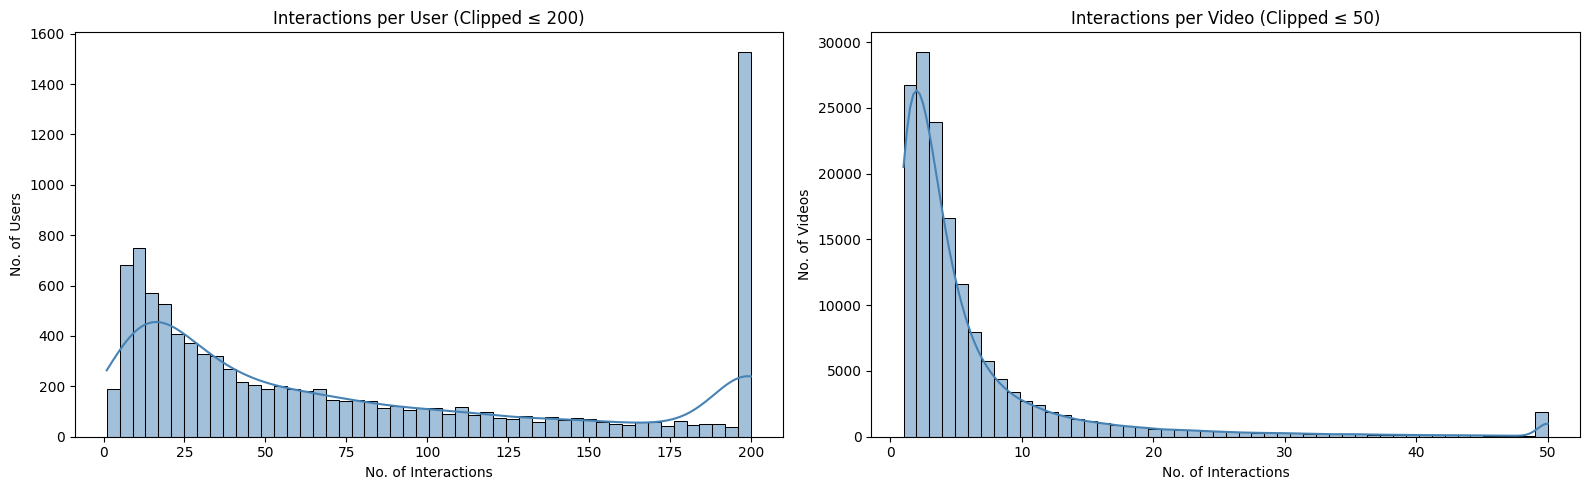

Interactions per user  -- median: 52, mean: 102.0, max: 2,228
Interactions per video -- median: 3, mean: 6.6, max: 1,193


In [49]:
# Interactions per user and per video
vids_per_user = behavior_df.groupby('user_id').size()
users_per_video = behavior_df.groupby('pid').size()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, data, title, ylabel in zip(axes, [vids_per_user.clip(upper=200), users_per_video.clip(upper=50)],
    ['Interactions per User (Clipped ≤ 200)', 'Interactions per Video (Clipped ≤ 50)'],
    ['No. of Users', 'No. of Videos']):
    sns.histplot(data, bins=50, kde=True, ax=ax, color='steelblue')
    ax.set(title=title, xlabel='No. of Interactions', ylabel=ylabel)

plt.tight_layout()
plt.show()

print(f"Interactions per user  -- median: {vids_per_user.median():.0f}, mean: {vids_per_user.mean():.1f}, max: {vids_per_user.max():,}")
print(f"Interactions per video -- median: {users_per_video.median():.0f}, mean: {users_per_video.mean():.1f}, max: {users_per_video.max():,}")

**Analysis:**

- **Interactions per user is right-skewed** with a median is 52, but mean is 102 and a maximum of 2,228. A small group of power users generates a disproportionate share of interactions. This suggests that user-level aggregated features should be **robust to outliers**.
- **Interactions per video is heavily right-skewed** with median is 3, but mean is 6.6 and a maximum of 1,193. Most videos receive very few impressions, creating a **cold-start problem** for video-side features. **Collaborative filtering signals will thus be sparse** for the majority of videos.
- The combination of active users and sparse video interactions creates an **asymmetric sparsity pattern**, where user-side features will be richer and more reliable than video-side features for most items in the catalogue.

### 2.6 Correlation Analysis

Pairwise correlations among numeric features at the interaction level.

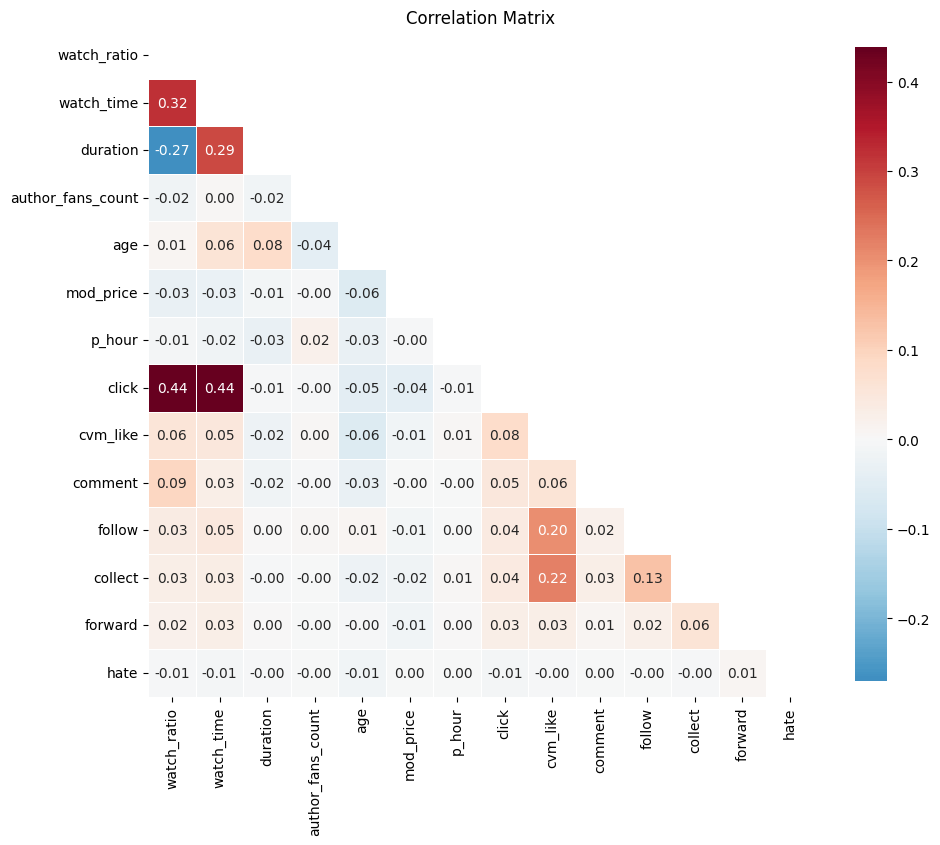

In [50]:
# Correlation analysis
corr_df = behavior_df.merge(user_df[['user_id', 'age', 'mod_price']], on='user_id', how='left')
corr_df = corr_df.merge(video_df[['pid', 'author_fans_count']], on='pid', how='left')

numeric_cols = ['watch_ratio', 'watch_time', 'duration', 'author_fans_count',
                'age', 'mod_price', 'p_hour',
                'click', 'cvm_like', 'comment', 'follow', 'collect', 'forward', 'hate']
corr = corr_df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=.5, ax=ax, cbar_kws={'shrink': .7})
ax.set(title='Correlation Matrix')
plt.tight_layout()
plt.show()

**Analysis:**
- **`watch_ratio` and `duration` have a negative correlation** (as seen in the scatter analysis), while **`watch_ratio` and `watch_time` are positively correlated**.
- **Engagement signals** (`cvm_like`, `comment`, `follow`, `collect`, `forward`) are **weakly but positively correlated** with both `watch_ratio` and `watch_time`. Users who watch longer are more likely to interact, but the correlations are modest (< 0.2), reflecting the low base rates of these signals.
- **`hate`** shows a **very slight negative or near-zero correlation** with watch ratio, consistent with disengagement.
- **User demographic features** (`age`, `mod_price`) show **near-zero correlations** with watch ratio, confirming earlier findings that demographics alone are weak predictors.
- **`author_fans_count`** has a very weak correlation with watch ratio, reinforcing that raw popularity is not a reliable indicator of per-interaction engagement.
- The engagement signals are **weakly correlated with each other**, which is good for modelling as they provide **largely independent signals**, rather than redundant information.